# Métodos híbridos: combinación de BM25 y SBERT sobre FiQA

**Propósito:**  
Comparar el rendimiento de métodos híbridos (BM25 + embeddings) frente a los sistemas puros, evaluando si la combinación de enfoques léxicos y semánticos mejora la recuperación de información.

**Archivos de entrada:**  
- ../results/results_bm25_lemmatize.csv  
- ../results/results_sbert_all-mpnet-base-v2.csv  
- ../data/subset_qrels_clean.csv


## Índice

1. [Introducción y objetivos](#1-introducción-y-objetivos)
2. [Carga de datos y preparación](#2-carga-de-datos-y-preparación)
3. [Normalización de scores](#3-normalización-de-scores)
4. [Combinación híbrida y ajuste de pesos](#4-combinación-híbrida-y-ajuste-de-pesos)
    - 4.1. Segundo intento de combinación híbrida
5. [Evaluación y análisis de resultados](#5-evaluación-y-análisis-de-resultados)
    - 5.1. Métricas agregadas (Precision@k, nDCG@k, MAP…)
    - 5.2. Comparativa con métodos puros e híbridos
6. [Re-ranking: BM25 + SBERT](#6-re-ranking:-BM25-+-SBERT)
---

## 1. Introducción y objetivos

En este notebook se exploran y evalúan métodos híbridos de recuperación de información, combinando las ventajas de BM25 y modelos de embeddings (SBERT, basados en similitud semántica) sobre el subset limpio del dataset FiQA.

---
## 2. Carga de datos y preparación


In [2]:
import pandas as pd

# Cargar  BM25, MiniLM y MPNet
bm25 = pd.read_csv("../results/results_bm25_lemmatize.csv")
minilm = pd.read_csv("../results/results_sbert_faiss_all-MiniLM-L6-v2.csv")
mpnet = pd.read_csv("../results/results_sbert_faiss_all-mpnet-base-v2.csv")

print("BM25:")
display(bm25.head())
print(bm25.columns)

print("\nMiniLM:")
display(minilm.head())
print(minilm.columns)

print("\nMPNet:")
display(mpnet.head())
print(mpnet.columns)



BM25:


,query_id,doc_id,score,rank,is_relevant
0,3394,112208,16.945597,1,0
1,3394,172703,16.545998,2,0
2,3394,87722,16.122158,3,0
3,3394,445971,14.580649,4,1
4,3394,345199,14.421979,5,0


Index(['query_id', 'doc_id', 'score', 'rank', 'is_relevant'], dtype='object')

MiniLM:


,query_id,doc_id,rank,score
0,3394,445971,1,0.610437
1,3394,342258,2,0.543492
2,3394,528034,3,0.485324
3,3394,507777,4,0.481937
4,3394,112208,5,0.450805


Index(['query_id', 'doc_id', 'rank', 'score'], dtype='object')

MPNet:


,query_id,doc_id,rank,score
0,3394,342258,1,0.618945
1,3394,445971,2,0.581766
2,3394,570664,3,0.526457
3,3394,528034,4,0.472202
4,3394,489352,5,0.439590


Index(['query_id', 'doc_id', 'rank', 'score'], dtype='object')


In [3]:
# Renombrar las columnas 'score'
bm25_ = bm25.rename(columns={'score': 'bm25_score'})
minilm_ = minilm.rename(columns={'score': 'minilm_score'})
mpnet_ = mpnet.rename(columns={'score': 'mpnet_score'})

df_hybrid = bm25_[['query_id', 'doc_id', 'bm25_score']] \
    .merge(minilm_[['query_id', 'doc_id', 'minilm_score']], on=['query_id', 'doc_id'], how='inner') \
    .merge(mpnet_[['query_id', 'doc_id', 'mpnet_score']], on=['query_id', 'doc_id'], how='inner')

print(f"Shape del DataFrame híbrido: {df_hybrid.shape}")
display(df_hybrid.head())

# pares perdidos?
print(f"Total pares en BM25: {bm25_.shape[0]} - Total pares en híbrido: {df_hybrid.shape[0]}")


Shape del DataFrame híbrido: (3000, 5)


,query_id,doc_id,bm25_score,minilm_score,mpnet_score
0,3394,112208,16.945597,0.450805,0.434303
1,3394,172703,16.545998,0.234749,0.196172
2,3394,87722,16.122158,0.276085,0.155210
3,3394,445971,14.580649,0.610437,0.581766
4,3394,345199,14.421979,0.273926,0.201639


Total pares en BM25: 3000 - Total pares en híbrido: 3000


---
## 3. Normalización de scores

In [5]:
print("Rango global de scores:")
print(f"BM25:    min = {df_hybrid['bm25_score'].min():.3f}, max = {df_hybrid['bm25_score'].max():.3f}")
print(f"MiniLM:  min = {df_hybrid['minilm_score'].min():.3f}, max = {df_hybrid['minilm_score'].max():.3f}")
print(f"MPNet:   min = {df_hybrid['mpnet_score'].min():.3f}, max = {df_hybrid['mpnet_score'].max():.3f}")

Rango global de scores:
BM25:    min = 0.000, max = 48.127
MiniLM:  min = -0.201, max = 0.884
MPNet:   min = -0.115, max = 0.877


In [6]:
def minmax_normalize(df, score_col, group_col='query_id'):
    return df.groupby(group_col)[score_col].transform(
        lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) > 0 else 0.0
    )

# columnas normalizadas para cada score
df_hybrid['bm25_norm'] = minmax_normalize(df_hybrid, 'bm25_score')
df_hybrid['minilm_norm'] = minmax_normalize(df_hybrid, 'minilm_score')
df_hybrid['mpnet_norm'] = minmax_normalize(df_hybrid, 'mpnet_score')

display(df_hybrid.head())

q_id = df_hybrid['query_id'].iloc[0]
df_q = df_hybrid[df_hybrid['query_id'] == q_id]
print("Valores normalizados (primera query):")
print(df_q[['bm25_norm', 'minilm_norm', 'mpnet_norm']].describe())


,query_id,doc_id,bm25_score,minilm_score,mpnet_score,bm25_norm,minilm_norm,mpnet_norm
0,3394,112208,16.945597,0.450805,0.434303,1.000000,0.595684,0.654293
1,3394,172703,16.545998,0.234749,0.196172,0.920330,0.048456,0.096029
2,3394,87722,16.122158,0.276085,0.155210,0.835827,0.153152,0.000000
3,3394,445971,14.580649,0.610437,0.581766,0.528488,1.000000,1.000000
4,3394,345199,14.421979,0.273926,0.201639,0.496853,0.147684,0.108844


Valores normalizados (primera query):
       bm25_norm  minilm_norm  mpnet_norm
count  10.000000    10.000000   10.000000
mean    0.490259     0.300275    0.226422
std     0.341876     0.302579    0.329900
min     0.000000     0.000000    0.000000
25%     0.333225     0.137576    0.063971
50%     0.439780     0.175564    0.090318
75%     0.758992     0.381289    0.149641
max     1.000000     1.000000    1.000000


---
## 4. Combinación híbrida y ajuste de pesos

Se exploran diferentes valores de alpha (de 0 a 1) para:
- **BM25 + MiniLM**: combinando los scores normalizados de BM25 y MiniLM en distintas proporciones mediante un peso α (alpha).
- **BM25 + MPNet**: igual, pero usando los scores de MPNet.

In [7]:
import numpy as np

alphas = np.arange(0, 1.01, 0.1)
results_hybrid = []

In [14]:
import numpy as np

def precision_at_k(actual, predicted, k):
    return len(set(predicted[:k]) & set(actual)) / k

def recall_at_k(actual, predicted, k):
    return len(set(predicted[:k]) & set(actual)) / len(actual) if actual else 0.0

def dcg_at_k(relevances, k):
    relevances = np.asarray(relevances, dtype=float)[:k]
    if relevances.size:
        return relevances[0] + np.sum(relevances[1:] / np.log2(np.arange(2, relevances.size + 1)))
    return 0.0

def ndcg_at_k(actual, predicted, k):
    if not actual:
        return 0.0
    predicted_rels = [1 if doc in actual else 0 for doc in predicted[:k]]
    ideal_rels = sorted(predicted_rels, reverse=True)
    dcg = dcg_at_k(predicted_rels, k)
    idcg = dcg_at_k(ideal_rels, k)
    return dcg / idcg if idcg > 0 else 0.0

def apk(actual, predicted, k):
    if len(predicted) > k:
        predicted = predicted[:k]
    score = 0.0
    num_hits = 0.0
    for i, p in enumerate(predicted):
        if p in actual and p not in predicted[:i]:
            num_hits += 1.0
            score += num_hits / (i + 1.0)
    return score / min(len(actual), k) if actual else 0.0

def mean_average_precision(actual, predicted, k):
    return apk(actual, predicted, k)


In [15]:
alphas = np.arange(0, 1.01, 0.1)
ks = [1, 3, 5, 10]
qrels = pd.read_csv("../data/subset_qrels_clean.csv")
query_ids = df_hybrid['query_id'].unique()

def eval_hybrid(df_hybrid, norm_col, model_name):
    results = []
    for alpha in alphas:
        df_hybrid['score_hybrid'] = alpha * df_hybrid['bm25_norm'] + (1 - alpha) * df_hybrid[norm_col]
        metrics_total = {f'Precision@{k}': [] for k in ks}
        metrics_total.update({f'Recall@{k}': [] for k in ks})
        metrics_total.update({f'nDCG@{k}': [] for k in ks})
        metrics_total.update({f'MAP@{k}': [] for k in ks})
        
        for qid in query_ids:
            docs_gt = set(qrels[qrels['query_id'] == qid]['doc_id'])
            df_q = df_hybrid[df_hybrid['query_id'] == qid].sort_values('score_hybrid', ascending=False)
            docs_pred = df_q['doc_id'].tolist()
            for k in ks:
                metrics_total[f'Precision@{k}'].append(precision_at_k(docs_gt, docs_pred, k))
                metrics_total[f'Recall@{k}'].append(recall_at_k(docs_gt, docs_pred, k))
                metrics_total[f'nDCG@{k}'].append(ndcg_at_k(docs_gt, docs_pred, k))
                metrics_total[f'MAP@{k}'].append(mean_average_precision(docs_gt, docs_pred, k))
        
        results_row = {metric: np.mean(vals) for metric, vals in metrics_total.items()}
        results_row['MAP'] = np.mean([mean_average_precision(
            set(qrels[qrels['query_id'] == qid]['doc_id']),
            df_hybrid[df_hybrid['query_id'] == qid].sort_values('score_hybrid', ascending=False)['doc_id'].tolist(),
            10
        ) for qid in query_ids])
        results_row['alpha_bm25'] = alpha
        results_row['alpha_'+model_name] = 1 - alpha
        results.append(results_row)
        
        df_ranked = df_hybrid.copy()
        df_ranked['rank'] = df_ranked.groupby('query_id')['score_hybrid'].rank(ascending=False, method='first')
        df_ranked[df_ranked['rank'] <= 10][['query_id', 'doc_id', 'score_hybrid', 'rank']].to_csv(
            f"../results/results_hybrid_bm25_{model_name}_alpha{alpha:.2f}.csv", index=False
        )
    df_metrics = pd.DataFrame(results)
    df_metrics.to_csv(f"../results/summary_metrics_hybrid_bm25_{model_name}.csv", index=False)
    return df_metrics

df_metrics_minilm = eval_hybrid(df_hybrid, 'minilm_norm', 'minilm')
df_metrics_mpnet = eval_hybrid(df_hybrid, 'mpnet_norm', 'mpnet')

display(df_metrics_minilm)
display(df_metrics_mpnet)


,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP@1,MAP@3,MAP@5,MAP@10,MAP,alpha_bm25,alpha_minilm
0,0.636667,0.348889,0.240000,0.130333,0.346479,0.478018,0.526163,0.552623,0.636667,0.683392,0.686520,0.679186,0.636667,0.507593,0.494971,0.489983,0.489983,0.0,1.0
1,0.640000,0.350000,0.240000,0.130333,0.349706,0.478962,0.525163,0.552623,0.640000,0.685852,0.690074,0.680686,0.640000,0.511759,0.498576,0.493609,0.493609,0.1,0.9
2,0.636667,0.350000,0.241333,0.130333,0.346095,0.479907,0.527941,0.552623,0.636667,0.687955,0.690907,0.681763,0.636667,0.509259,0.497487,0.491709,0.491709,0.2,0.8
3,0.613333,0.348889,0.241333,0.130333,0.333873,0.484708,0.528496,0.552623,0.613333,0.682419,0.681706,0.677852,0.613333,0.501759,0.490594,0.484801,0.484801,0.3,0.7
4,0.600000,0.347778,0.240667,0.130333,0.325262,0.483380,0.526084,0.552623,0.600000,0.674522,0.675460,0.672112,0.600000,0.495278,0.483312,0.477423,0.477423,0.4,0.6
5,0.560000,0.336667,0.237333,0.130333,0.305123,0.472269,0.517473,0.552623,0.560000,0.656626,0.665382,0.661536,0.560000,0.472685,0.464289,0.460860,0.460860,0.5,0.5
6,0.530000,0.332222,0.237333,0.130333,0.289178,0.468380,0.515532,0.552623,0.530000,0.646883,0.659966,0.655356,0.530000,0.459815,0.453732,0.450186,0.450186,0.6,0.4
7,0.513333,0.322222,0.233333,0.130333,0.271956,0.454936,0.510434,0.552623,0.513333,0.631089,0.643141,0.640133,0.513333,0.441111,0.436846,0.435717,0.435717,0.7,0.3
8,0.486667,0.307778,0.227333,0.130333,0.258345,0.437047,0.503292,0.552623,0.486667,0.612677,0.631302,0.628531,0.486667,0.422685,0.422082,0.423317,0.423317,0.8,0.2
9,0.476667,0.294444,0.223333,0.130333,0.252234,0.422538,0.498875,0.552623,0.476667,0.599344,0.619862,0.616633,0.476667,0.406019,0.411687,0.413960,0.413960,0.9,0.1


,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP@1,MAP@3,MAP@5,MAP@10,MAP,alpha_bm25,alpha_mpnet
0,0.673333,0.370000,0.252000,0.130333,0.368655,0.505300,0.540484,0.552623,0.673333,0.703134,0.705611,0.703312,0.673333,0.544074,0.528521,0.516291,0.516291,0.0,1.0
1,0.666667,0.371111,0.252000,0.130333,0.367543,0.506411,0.540484,0.552623,0.666667,0.703134,0.705546,0.703340,0.666667,0.544815,0.528818,0.516712,0.516712,0.1,0.9
2,0.650000,0.368889,0.252000,0.130333,0.361849,0.501392,0.540484,0.552623,0.650000,0.701904,0.701999,0.699743,0.650000,0.537222,0.523606,0.511538,0.511538,0.2,0.8
3,0.630000,0.363333,0.250000,0.130333,0.350349,0.499337,0.537318,0.552623,0.630000,0.700059,0.696368,0.694976,0.630000,0.525370,0.513702,0.502633,0.502633,0.3,0.7
4,0.603333,0.362222,0.248667,0.130333,0.330349,0.499503,0.535429,0.552623,0.603333,0.698828,0.693763,0.691802,0.603333,0.514259,0.501231,0.491025,0.491025,0.4,0.6
5,0.570000,0.346667,0.245333,0.130333,0.311071,0.480416,0.531318,0.552623,0.570000,0.683392,0.682118,0.677927,0.570000,0.487963,0.480914,0.472532,0.472532,0.5,0.5
6,0.536667,0.336667,0.242667,0.130333,0.289734,0.471773,0.527675,0.552623,0.536667,0.667241,0.667795,0.662759,0.536667,0.465000,0.462184,0.455218,0.455218,0.6,0.4
7,0.506667,0.322222,0.236667,0.130333,0.268067,0.455658,0.519522,0.552623,0.506667,0.640217,0.648833,0.645005,0.506667,0.439537,0.439174,0.436289,0.436289,0.7,0.3
8,0.493333,0.311111,0.231333,0.130333,0.262789,0.438603,0.509403,0.552623,0.493333,0.618729,0.639227,0.634004,0.493333,0.426667,0.428153,0.427803,0.427803,0.8,0.2
9,0.480000,0.293333,0.224000,0.130333,0.253345,0.419482,0.499569,0.552623,0.480000,0.599344,0.619092,0.617464,0.480000,0.404722,0.412427,0.414819,0.414819,0.9,0.1


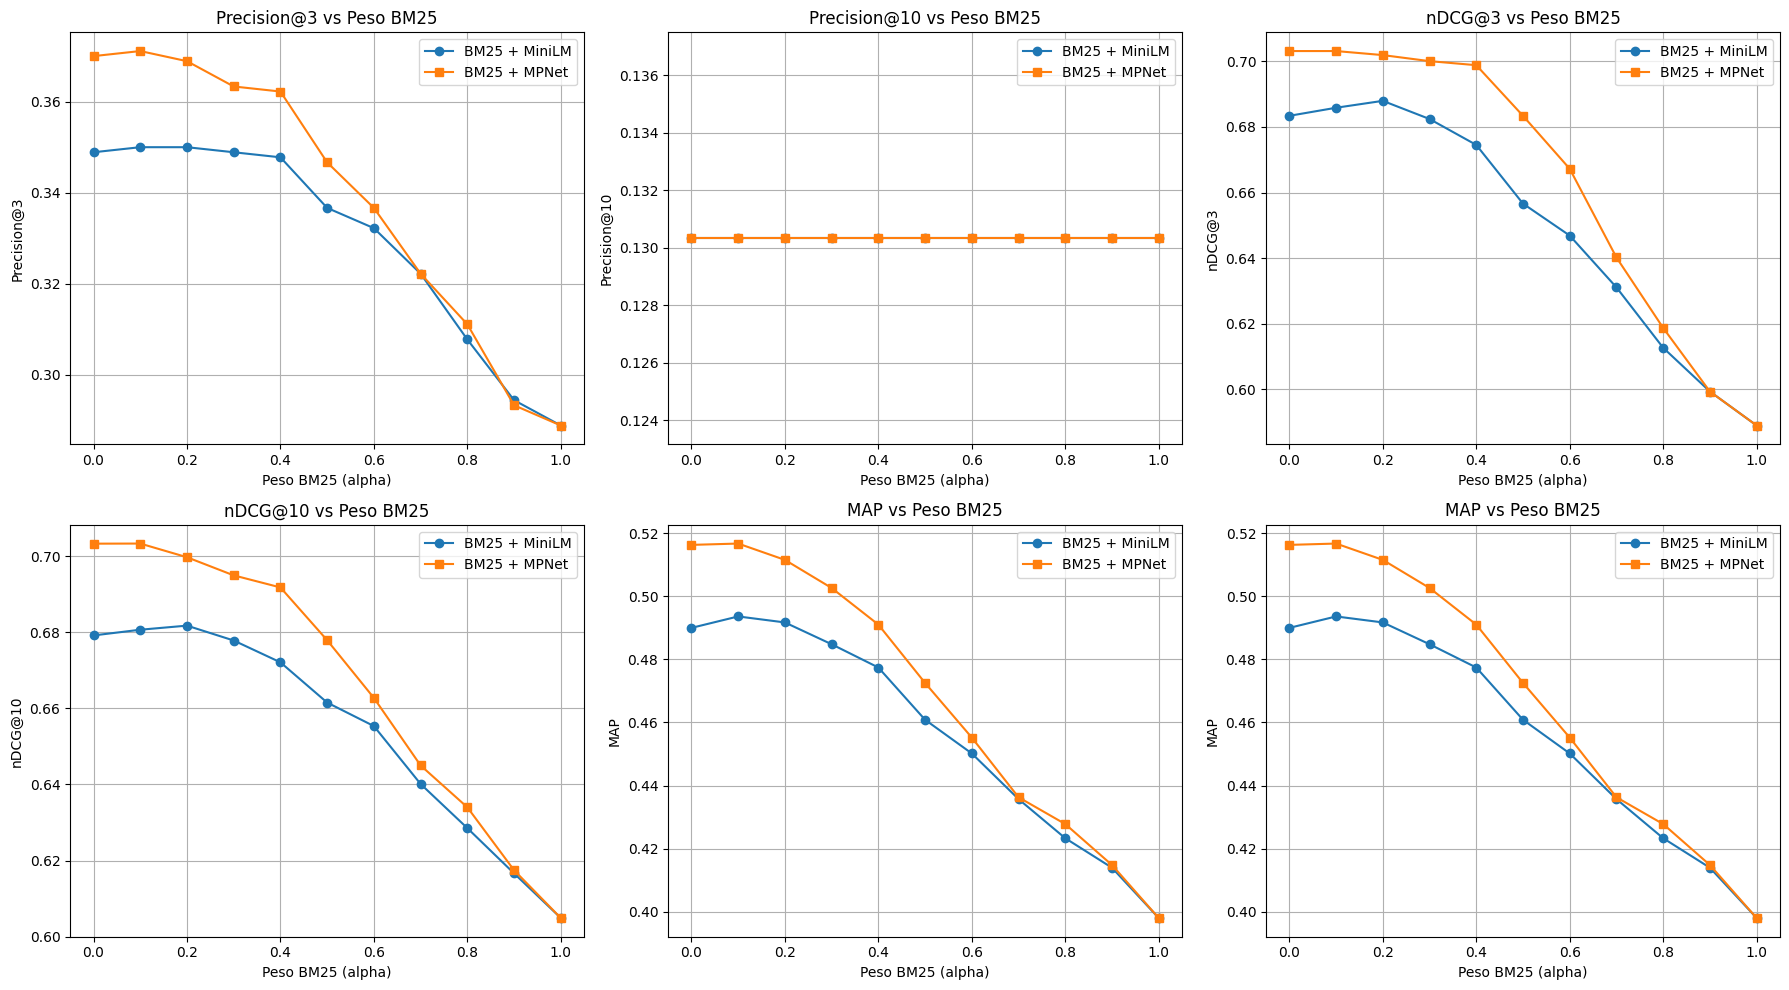

In [16]:
import matplotlib.pyplot as plt

# Cargar métricas guardadas
df_minilm = pd.read_csv("../results/summary_metrics_hybrid_bm25_minilm.csv")
df_mpnet = pd.read_csv("../results/summary_metrics_hybrid_bm25_mpnet.csv")

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
metrics = ['Precision@3', 'Precision@10', 'nDCG@3', 'nDCG@10', 'MAP']

for idx, metric in enumerate(metrics):
    row = idx // 3
    col = idx % 3
    ax = axes[row, col]
    ax.plot(df_minilm['alpha_bm25'], df_minilm[metric], marker='o', label='BM25 + MiniLM')
    ax.plot(df_mpnet['alpha_bm25'], df_mpnet[metric], marker='s', label='BM25 + MPNet')
    ax.set_xlabel('Peso BM25 (alpha)')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} vs Peso BM25')
    ax.legend()
    ax.grid(True)

# MAP
axes[1,2].plot(df_minilm['alpha_bm25'], df_minilm['MAP'], marker='o', label='BM25 + MiniLM')
axes[1,2].plot(df_mpnet['alpha_bm25'], df_mpnet['MAP'], marker='s', label='BM25 + MPNet')
axes[1,2].set_xlabel('Peso BM25 (alpha)')
axes[1,2].set_ylabel('MAP')
axes[1,2].set_title('MAP vs Peso BM25')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout()
plt.show()


In [ ]:
metrics = ['Precision@1', 'Recall@1', 'nDCG@1',
           'Precision@3', 'Recall@3', 'nDCG@3',
           'Precision@5', 'Recall@5', 'nDCG@5',
           'Precision@10', 'Recall@10', 'nDCG@10', 'MAP']

print("=== BM25 + MiniLM ===")
for metric in metrics:
    idx = df_minilm[metric].idxmax()
    alpha = df_minilm.loc[idx, 'alpha_bm25']
    value = df_minilm.loc[idx, metric]
    print(f"{metric}: {value:.3f} (alpha_bm25 = {alpha:.2f})")

print("\n=== BM25 + MPNet ===")
for metric in metrics:
    idx = df_mpnet[metric].idxmax()
    alpha = df_mpnet.loc[idx, 'alpha_bm25']
    value = df_mpnet.loc[idx, metric]
    print(f"{metric}: {value:.3f} (alpha_bm25 = {alpha:.2f})")


=== BM25 + MiniLM ===
Precision@1: 0.640 (alpha_bm25 = 0.10)
Recall@1: 0.350 (alpha_bm25 = 0.10)
nDCG@1: 0.640 (alpha_bm25 = 0.10)
Precision@3: 0.350 (alpha_bm25 = 0.10)
Recall@3: 0.485 (alpha_bm25 = 0.30)
nDCG@3: 0.688 (alpha_bm25 = 0.20)
Precision@5: 0.241 (alpha_bm25 = 0.20)
Recall@5: 0.528 (alpha_bm25 = 0.30)
nDCG@5: 0.691 (alpha_bm25 = 0.20)
Precision@10: 0.130 (alpha_bm25 = 0.00)
Recall@10: 0.553 (alpha_bm25 = 0.00)
nDCG@10: 0.682 (alpha_bm25 = 0.20)
MAP: 0.494 (alpha_bm25 = 0.10)

=== BM25 + MPNet ===
Precision@1: 0.673 (alpha_bm25 = 0.00)
Recall@1: 0.369 (alpha_bm25 = 0.00)
nDCG@1: 0.673 (alpha_bm25 = 0.00)
Precision@3: 0.371 (alpha_bm25 = 0.10)
Recall@3: 0.506 (alpha_bm25 = 0.10)
nDCG@3: 0.703 (alpha_bm25 = 0.00)
Precision@5: 0.252 (alpha_bm25 = 0.00)
Recall@5: 0.540 (alpha_bm25 = 0.00)
nDCG@5: 0.706 (alpha_bm25 = 0.00)
Precision@10: 0.130 (alpha_bm25 = 0.00)
Recall@10: 0.553 (alpha_bm25 = 0.00)
nDCG@10: 0.703 (alpha_bm25 = 0.10)
MAP: 0.517 (alpha_bm25 = 0.10)


In [31]:
df = pd.read_csv("../results/summary_metrics_models.csv", index_col=0)

df = df.dropna(how="all")

df_t = df.T

# MAP descendente
df_sorted = df_t.sort_values(by="MAP", ascending=False)

print(df_sorted.round(3))



                Precision@1  Recall@1  nDCG@1  Precision@3  Recall@3  nDCG@3  \
SBERT_MPNet           0.773     0.423   0.773        0.497     0.671   0.740   
SBERT_MiniLM          0.680     0.362   0.680        0.412     0.550   0.624   
BM25_lemmatize        0.450     0.236   0.450        0.289     0.413   0.440   

                Precision@10  Recall@10  nDCG@10    MAP  
SBERT_MPNet            0.213      0.848    0.783  0.730  
SBERT_MiniLM           0.184      0.732    0.669  0.611  
BM25_lemmatize         0.130      0.553    0.479  0.397  


In [34]:
import pandas as pd

df = pd.read_csv("../results/summary_metrics_models.csv", index_col=0)

df["BM25 + MiniLM"] = [
    0.640,   # Precision@1
    0.350,   # Recall@1
    0.640,   # nDCG@1
    0.350,   # Precision@3
    0.485,   # Recall@3
    0.688,   # nDCG@3
    0.130,   # Precision@10
    0.553,   # Recall@10
    0.682,   # nDCG@10
    0.494    # MAP
]

df["BM25 + MPNet"] = [
    0.673,   # Precision@1
    0.369,   # Recall@1
    0.673,   # nDCG@1
    0.371,   # Precision@3
    0.506,   # Recall@3
    0.703,   # nDCG@3
    0.130,   # Precision@10
    0.553,   # Recall@10
    0.703,   # nDCG@10
    0.517    # MAP
]

df.to_csv("../results/summary_metrics_models.csv")



In [35]:
df = pd.read_csv("../results/summary_metrics_models.csv", index_col=0)
df = df.dropna(how="all")
df_t = df.T
df_sorted = df_t.sort_values(by="MAP", ascending=False)
print(df_sorted.round(3))


                Precision@1  Recall@1  nDCG@1  Precision@3  Recall@3  nDCG@3  \
SBERT_MPNet           0.773     0.423   0.773        0.497     0.671   0.740   
SBERT_MiniLM          0.680     0.362   0.680        0.412     0.550   0.624   
BM25 + MPNet          0.673     0.369   0.673        0.371     0.506   0.703   
BM25 + MiniLM         0.640     0.350   0.640        0.350     0.485   0.688   
BM25_lemmatize        0.450     0.236   0.450        0.289     0.413   0.440   

                Precision@10  Recall@10  nDCG@10    MAP  
SBERT_MPNet            0.213      0.848    0.783  0.730  
SBERT_MiniLM           0.184      0.732    0.669  0.611  
BM25 + MPNet           0.130      0.553    0.703  0.517  
BM25 + MiniLM          0.130      0.553    0.682  0.494  
BM25_lemmatize         0.130      0.553    0.479  0.397  


#### **Análisis de resultados híbridos**

En general, las combinaciones híbridas suelen mejorar el rendimiento, pero en este caso no ha sido así. Aunque BM25 + SBERT mejora ligeramente respecto a BM25, no supera a los modelos SBERT por separado.

Probablemente esto se debe a que hemos usado una interpolación lineal simple con normalización min-max, lo cual puede haber distorsionado los scores. Además, el tipo de corpus y la diferencia de escalas entre modelos hacen que este tipo de combinación no sea suficiente.

Se necesitan técnicas más avanzadas para mejorar los resultados.

---

## 4.1. Segundo intento de combinación híbrida

- Normalización por query: En este segundo intento, normalizaremos los scores por query en lugar de hacerlo globalmente, lo que permite una comparación más justa dentro del contexto de cada búsqueda.

- Nuevas combinaciones no lineales

In [36]:
# Normalización por query
from sklearn.preprocessing import MinMaxScaler

df_hybrid_qnorm = df_hybrid.copy()

for col in ['bm25_score', 'minilm_score', 'mpnet_score']:
    df_hybrid_qnorm[f'{col}_norm'] = (
        df_hybrid_qnorm
        .groupby('query_id')[col]
        .transform(lambda x: MinMaxScaler().fit_transform(x.values.reshape(-1, 1)).flatten())
    )

# ejemplo
query_ejemplo = df_hybrid_qnorm.query_id.unique()[0]
display(df_hybrid_qnorm[df_hybrid_qnorm.query_id == query_ejemplo].head(10))


,query_id,doc_id,bm25_score,minilm_score,mpnet_score,bm25_norm,minilm_norm,mpnet_norm,score_hybrid,bm25_score_norm,minilm_score_norm,mpnet_score_norm
0,3394,112208,16.945597,0.450805,0.434303,1.000000,0.595684,0.654293,1.000000,1.000000,0.595684,0.654293
1,3394,172703,16.545998,0.234749,0.196172,0.920330,0.048456,0.096029,0.920330,0.920330,0.048456,0.096029
2,3394,87722,16.122158,0.276085,0.155210,0.835827,0.153152,0.000000,0.835827,0.835827,0.153152,0.000000
3,3394,445971,14.580649,0.610437,0.581766,0.528488,1.000000,1.000000,0.528488,0.528488,1.000000,1.000000
4,3394,345199,14.421979,0.273926,0.201639,0.496853,0.147684,0.108844,0.496853,0.496853,0.147684,0.108844
5,3394,377429,13.849465,0.268605,0.182041,0.382708,0.134206,0.062900,0.382708,0.382708,0.134206,0.062900
6,3394,387277,13.729941,0.373458,0.224841,0.358878,0.399780,0.163239,0.358878,0.358878,0.399780,0.163239
7,3394,133093,13.558391,0.344256,0.191300,0.324675,0.325816,0.084606,0.324675,0.324675,0.325816,0.084606
8,3394,418150,12.204958,0.215617,0.166781,0.054833,0.000000,0.027126,0.054833,0.054833,0.000000,0.027126
9,3394,539263,11.929931,0.293782,0.183868,0.000000,0.197976,0.067183,0.000000,0.000000,0.197976,0.067183


In [ ]:
df_bm25 = pd.read_csv("../results/results_bm25_lemmatize.csv")
print(df_bm25.columns)

cols_needed = ['query_id', 'doc_id', 'is_relevant']
if all(col in df_bm25.columns for col in cols_needed):
    df_hybrid = df_hybrid.merge(df_bm25[cols_needed], on=['query_id', 'doc_id'], how='left')
else:
    raise ValueError("fail")

Index(['query_id', 'doc_id', 'score', 'rank', 'is_relevant'], dtype='object')


In [46]:
from tqdm import tqdm

# Funciones de combinación
def linear_combo(bm25, sbert, alpha):
    return alpha * bm25 + (1 - alpha) * sbert

def geometric_mean(bm25, sbert, alpha):
    return np.power(bm25, alpha) * np.power(sbert, 1 - alpha)

def log_weighted(bm25, sbert, alpha):
    return alpha * np.log1p(bm25) + (1 - alpha) * np.log1p(sbert)

def multiplicative(bm25, sbert, alpha=None):
    return bm25 * sbert  # alpha no se usa

def max_score(bm25, sbert, alpha=None):
    return np.maximum(bm25, sbert)

In [ ]:
""" 
def evaluar_hibrido(df, bm25_col, sbert_col, combine_func, alpha, method_name, model_name):
    if alpha is None:
        col_name = f'{method_name}_{model_name}'
    else:
        col_name = f'{method_name}_{model_name}_a{alpha:.2f}'

    df = df.copy()
    df['score'] = combine_func(df[bm25_col], df[sbert_col], alpha)

    from src.evaluation.metrics import precision_at_k, recall_at_k, ndcg_at_k, mean_average_precision

    ks = [1, 3, 5, 10]
    metrics_total = {f'{m}@{k}': [] for m in ['Precision', 'Recall', 'nDCG'] for k in ks}
    metrics_total['MAP'] = []

    for qid, group in df.groupby('query_id'):
        docs_gt = group[group['is_relevant'] == 1]['doc_id'].tolist()
        docs_pred = group.sort_values('score', ascending=False)['doc_id'].tolist()
        for k in ks:
            metrics_total[f'Precision@{k}'].append(precision_at_k(docs_gt, docs_pred, k))
            metrics_total[f'Recall@{k}'].append(recall_at_k(docs_gt, docs_pred, k))
            metrics_total[f'nDCG@{k}'].append(ndcg_at_k(docs_gt, docs_pred, k))
        metrics_total['MAP'].append(mean_average_precision(docs_gt, docs_pred, k=10))

    return {
        'method': method_name,
        'model': model_name,
        'alpha': alpha,
        **{metric: np.mean(vals) for metric, vals in metrics_total.items()}
    }
"""


In [ ]:
df_bm25 = pd.read_csv("../results/results_bm25_lemmatize.csv")

print(df_bm25.columns)

cols_needed = ['query_id', 'doc_id', 'is_relevant']
if all(col in df_bm25.columns for col in cols_needed):
    df_hybrid = df_hybrid.merge(df_bm25[cols_needed], on=['query_id', 'doc_id'], how='left')
else:
    raise ValueError("Missing required columns in df_bm25")

print(df_hybrid.columns)


Index(['query_id', 'doc_id', 'score', 'rank', 'is_relevant'], dtype='object')
Index(['query_id', 'doc_id', 'bm25_score', 'minilm_score', 'mpnet_score',
       'bm25_norm', 'minilm_norm', 'mpnet_norm', 'score_hybrid', 'linear_0.0',
       'is_relevant'],
      dtype='object')


In [51]:
alphas = np.arange(0.05, 1.0, 0.05)
method_name = 'linear'
combine_func = linear_combo

results = []

for alpha in alphas:
    # MiniLM
    res_minilm = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='minilm_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MiniLM'
    )
    results.append(res_minilm)

    # MPNet
    res_mpnet = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='mpnet_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MPNet'
    )
    results.append(res_mpnet)

# Convertir en DataFrame y mostrar
df_linear_all = pd.DataFrame(results)
display(df_linear_all)

df_linear_all.to_csv("../results/summary_metrics_linear_combo.csv", index=False)


,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP,method,model,alpha
0,0.633333,0.351111,0.240000,0.130333,0.453583,0.640639,0.696083,0.736667,0.633333,0.687955,0.690481,0.682507,0.646441,linear,MiniLM,0.05
1,0.670000,0.370000,0.252000,0.130333,0.489139,0.672306,0.721694,0.736667,0.670000,0.703749,0.706226,0.703876,0.682625,linear,MPNet,0.05
2,0.640000,0.350000,0.240000,0.130333,0.459694,0.636306,0.694972,0.736667,0.640000,0.685852,0.690074,0.680686,0.648158,linear,MiniLM,0.10
3,0.666667,0.371111,0.252000,0.130333,0.488472,0.673417,0.721694,0.736667,0.666667,0.703134,0.705546,0.703340,0.682565,linear,MPNet,0.10
4,0.633333,0.348889,0.241333,0.130333,0.453028,0.635194,0.699694,0.736667,0.633333,0.684622,0.689251,0.680122,0.644429,linear,MiniLM,0.15
5,0.663333,0.371111,0.252000,0.130333,0.485139,0.673694,0.721694,0.736667,0.663333,0.700674,0.703227,0.701021,0.679468,linear,MPNet,0.15
6,0.636667,0.350000,0.241333,0.130333,0.458028,0.637694,0.699694,0.736667,0.636667,0.687955,0.690907,0.681763,0.647767,linear,MiniLM,0.20
7,0.650000,0.368889,0.252000,0.130333,0.478472,0.669250,0.721694,0.736667,0.650000,0.701904,0.701999,0.699743,0.674620,linear,MPNet,0.20
8,0.623333,0.348889,0.240667,0.130333,0.446361,0.636028,0.697361,0.736667,0.623333,0.686110,0.686276,0.679881,0.640109,linear,MiniLM,0.25
9,0.636667,0.363333,0.251333,0.130333,0.466250,0.662028,0.718361,0.736667,0.636667,0.705595,0.701307,0.700226,0.667834,linear,MPNet,0.25


In [55]:
method_name = 'geometric'
combine_func = geometric_mean

results = []

for alpha in alphas:
    # MiniLM
    res_minilm = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='minilm_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MiniLM'
    )
    results.append(res_minilm)

    # MPNet
    res_mpnet = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='mpnet_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MPNet'
    )
    results.append(res_mpnet)

df_geometric_all = pd.DataFrame(results)
display(df_geometric_all)

df_geometric_all.to_csv("../results/summary_metrics_geometric_combo.csv", index=False)


,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP,method,model,alpha
0,0.636667,0.344444,0.236000,0.130333,0.456361,0.628972,0.687194,0.736667,0.636667,0.685852,0.689964,0.675745,0.640949,geometric,MiniLM,0.05
1,0.666667,0.365556,0.246667,0.130333,0.488472,0.665083,0.711972,0.736667,0.666667,0.703134,0.708567,0.696915,0.674958,geometric,MPNet,0.05
2,0.633333,0.342222,0.239333,0.130333,0.453028,0.621861,0.692028,0.736667,0.633333,0.681646,0.687053,0.674369,0.638260,geometric,MiniLM,0.10
3,0.656667,0.364444,0.246667,0.130333,0.480139,0.661750,0.711972,0.736667,0.656667,0.702519,0.706553,0.695018,0.669013,geometric,MPNet,0.10
4,0.630000,0.343333,0.240667,0.130333,0.451361,0.626306,0.693806,0.736667,0.630000,0.684007,0.683963,0.674489,0.637301,geometric,MiniLM,0.15
5,0.640000,0.361111,0.246000,0.130333,0.470139,0.654250,0.706972,0.736667,0.640000,0.696467,0.699160,0.691252,0.661027,geometric,MPNet,0.15
6,0.620000,0.343333,0.240000,0.130333,0.443028,0.626306,0.692139,0.736667,0.620000,0.680674,0.683974,0.674263,0.632953,geometric,MiniLM,0.20
7,0.630000,0.357778,0.245333,0.130333,0.459583,0.650639,0.703639,0.736667,0.630000,0.695852,0.694883,0.688317,0.653523,geometric,MPNet,0.20
8,0.613333,0.342222,0.239333,0.130333,0.440806,0.622972,0.693139,0.736667,0.613333,0.675495,0.683304,0.671246,0.630133,geometric,MiniLM,0.25
9,0.623333,0.351111,0.243333,0.130333,0.452917,0.640083,0.700472,0.736667,0.623333,0.693749,0.692649,0.684932,0.646180,geometric,MPNet,0.25


In [56]:
alphas = np.arange(0.05, 1.0, 0.05)
method_name = 'log_weighted'
combine_func = log_weighted

results = []

for alpha in alphas:
    # MiniLM
    res_minilm = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='minilm_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MiniLM'
    )
    results.append(res_minilm)

    # MPNet
    res_mpnet = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='mpnet_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MPNet'
    )
    results.append(res_mpnet)

df_log_all = pd.DataFrame(results)
display(df_log_all)

df_log_all.to_csv("../results/summary_metrics_log_weighted_combo.csv", index=False)


,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP,method,model,alpha
0,0.633333,0.351111,0.239333,0.130333,0.453583,0.640639,0.694417,0.736667,0.633333,0.689186,0.692660,0.683049,0.646608,log_weighted,MiniLM,0.05
1,0.670000,0.370000,0.252000,0.130333,0.489139,0.672306,0.721694,0.736667,0.670000,0.704364,0.706841,0.704491,0.683180,log_weighted,MPNet,0.05
2,0.636667,0.350000,0.240667,0.130333,0.456361,0.636306,0.698306,0.736667,0.636667,0.685852,0.691509,0.680833,0.646603,log_weighted,MiniLM,0.10
3,0.666667,0.371111,0.252000,0.130333,0.488472,0.673417,0.721694,0.736667,0.666667,0.701904,0.704315,0.702109,0.682010,log_weighted,MPNet,0.10
4,0.633333,0.347778,0.241333,0.130333,0.454694,0.633528,0.699694,0.736667,0.633333,0.684007,0.688024,0.678879,0.644170,log_weighted,MiniLM,0.15
5,0.663333,0.371111,0.252000,0.130333,0.486806,0.673694,0.721694,0.736667,0.663333,0.704007,0.703343,0.701137,0.680051,log_weighted,MPNet,0.15
6,0.633333,0.350000,0.242000,0.130333,0.454694,0.639917,0.701361,0.736667,0.633333,0.690059,0.689846,0.681640,0.645516,log_weighted,MiniLM,0.20
7,0.640000,0.367778,0.251333,0.130333,0.468472,0.667583,0.718361,0.736667,0.640000,0.703134,0.700845,0.699879,0.669620,log_weighted,MPNet,0.20
8,0.626667,0.351111,0.241333,0.130333,0.449694,0.638250,0.699028,0.736667,0.626667,0.684880,0.683962,0.679810,0.641914,log_weighted,MiniLM,0.25
9,0.630000,0.363333,0.250667,0.130333,0.461250,0.662028,0.718083,0.736667,0.630000,0.701904,0.696534,0.696218,0.662394,log_weighted,MPNet,0.25


In [67]:
def evaluar_hibrido(df, bm25_col, sbert_col, combine_func, alpha, method_name, model_name):
    if alpha is None:
        col_name = f'{method_name}_{model_name}'
    else:
        col_name = f'{method_name}_{model_name}_a{alpha:.2f}'

    df = df.copy()
    df['score'] = combine_func(df[bm25_col], df[sbert_col], alpha)

    ks = [1, 3, 5, 10]
    metrics_total = {f'{m}@{k}': [] for m in ['Precision', 'Recall', 'nDCG'] for k in ks}
    metrics_total['MAP'] = []

    for qid, group in df.groupby('query_id'):
        docs_gt = group[group['is_relevant'] == 1]['doc_id'].tolist()
        docs_pred = group.sort_values('score', ascending=False)['doc_id'].tolist()
        for k in ks:
            metrics_total[f'Precision@{k}'].append(precision_at_k(docs_gt, docs_pred, k))
            metrics_total[f'Recall@{k}'].append(recall_at_k(docs_gt, docs_pred, k))
            metrics_total[f'nDCG@{k}'].append(ndcg_at_k(docs_gt, docs_pred, k))
        metrics_total['MAP'].append(mean_average_precision(docs_gt, docs_pred, k=10))

    return {
        'method': method_name,
        'model': model_name,
        'alpha': alpha,
        **{metric: np.mean(vals) for metric, vals in metrics_total.items()}
    }


In [69]:
alphas = [None]  # alpha no se usa
method_name = 'multiplicative'
combine_func = multiplicative

results = []

for alpha in alphas:
    # MiniLM
    res_minilm = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='minilm_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MiniLM'
    )
    results.append(res_minilm)

    # MPNet
    res_mpnet = evaluar_hibrido(
        df=df_hybrid,
        bm25_col='bm25_norm',
        sbert_col='mpnet_norm',
        combine_func=combine_func,
        alpha=alpha,
        method_name=method_name,
        model_name='MPNet'
    )
    results.append(res_mpnet)

df_mult_all = pd.DataFrame(results)
display(df_mult_all)

df_mult_all.to_csv("../results/summary_metrics_multiplicative_combo.csv", index=False)



,method,model,alpha,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP
0,multiplicative,MiniLM,None,0.556667,0.328889,0.230667,0.130333,0.393028,0.600361,0.668028,0.736667,0.556667,0.586592,0.609622,0.635767,0.589694
1,multiplicative,MPNet,None,0.576667,0.335556,0.233333,0.130333,0.411806,0.612028,0.678472,0.736667,0.576667,0.605238,0.627420,0.650058,0.609262


In [ ]:
method_name = 'max_score'
combine_func = max_score

results = []

# MiniLM
res_minilm = evaluar_hibrido(
    df=df_hybrid,
    bm25_col='bm25_norm',
    sbert_col='minilm_norm',
    combine_func=combine_func,
    alpha=None,
    method_name=method_name,
    model_name='MiniLM'
)
results.append(res_minilm)

# MPNet
res_mpnet = evaluar_hibrido(
    df=df_hybrid,
    bm25_col='bm25_norm',
    sbert_col='mpnet_norm',
    combine_func=combine_func,
    alpha=None,
    method_name=method_name,
    model_name='MPNet'
)
results.append(res_mpnet)

# Guardar y mostrar resultados
df_maxscore_all = pd.DataFrame(results)
display(df_maxscore_all)

df_maxscore_all.to_csv("../results/summary_metrics_max_score_combo.csv", index=False)

,method,model,alpha,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP
0,max_score,MiniLM,None,0.45,0.344444,0.239333,0.130333,0.303583,0.628528,0.695528,0.736667,0.45,0.573567,0.596269,0.612677,0.561686
1,max_score,MPNet,None,0.45,0.355556,0.247333,0.130333,0.303583,0.650917,0.710306,0.736667,0.45,0.589142,0.610041,0.620125,0.573671


## 5. Evaluación y análisis de resultados

In [ ]:
import pandas as pd

df_linear = pd.read_csv("results/summary_metrics_linear_combo.csv")
df_geometric = pd.read_csv("results/summary_metrics_geometric_combo.csv")
df_log = pd.read_csv("results/summary_metrics_log_weighted_combo.csv")
df_mult = pd.read_csv("results/summary_metrics_multiplicative_combo.csv")
df_max = pd.read_csv("results/summary_metrics_max_score_combo.csv")

df_linear["method"] = "linear_combo"
df_geometric["method"] = "geometric_mean"
df_log["method"] = "log_weighted"
df_mult["method"] = "multiplicative"
df_max["method"] = "max_score"

In [12]:
top5_list = []

def top5_by_model(df, method_name):
    for model in df["model"].unique():
        sub = df[df["model"] == model].sort_values(by="MAP", ascending=False).head(5)
        top5_list.append(sub)

top5_by_model(df_linear, "linear_combo")
top5_by_model(df_geometric, "geometric_mean")
top5_by_model(df_log, "log_weighted")

finalistas = pd.concat([x.iloc[[0]] for x in top5_list], ignore_index=True)  # Solo el top 1 de cada pareja

finalistas = pd.concat([finalistas, df_mult, df_max], ignore_index=True)

cols_show = ["method", "model", "alpha", "MAP", "nDCG@10", "Precision@1", "Recall@10"]
finalistas = finalistas[cols_show]

for top5 in top5_list:
    print(f"\n--- TOP 5 {top5['method'].iloc[0]} ({top5['model'].iloc[0]}) ---")
    display(top5[cols_show])




--- TOP 5 linear_combo (MiniLM) ---


,method,model,alpha,MAP,nDCG@10,Precision@1,Recall@10
2,linear_combo,MiniLM,0.10,0.648158,0.680686,0.640000,0.736667
6,linear_combo,MiniLM,0.20,0.647767,0.681763,0.636667,0.736667
0,linear_combo,MiniLM,0.05,0.646441,0.682507,0.633333,0.736667
4,linear_combo,MiniLM,0.15,0.644429,0.680122,0.633333,0.736667
8,linear_combo,MiniLM,0.25,0.640109,0.679881,0.623333,0.736667



--- TOP 5 linear_combo (MPNet) ---


,method,model,alpha,MAP,nDCG@10,Precision@1,Recall@10
1,linear_combo,MPNet,0.05,0.682625,0.703876,0.670000,0.736667
3,linear_combo,MPNet,0.10,0.682565,0.703340,0.666667,0.736667
5,linear_combo,MPNet,0.15,0.679468,0.701021,0.663333,0.736667
7,linear_combo,MPNet,0.20,0.674620,0.699743,0.650000,0.736667
9,linear_combo,MPNet,0.25,0.667834,0.700226,0.636667,0.736667



--- TOP 5 geometric_mean (MiniLM) ---


...

,method,model,alpha,MAP,nDCG@10,Precision@1,Recall@10
1,geometric_mean,MPNet,0.05,0.674958,0.696915,0.666667,0.736667
3,geometric_mean,MPNet,0.10,0.669013,0.695018,0.656667,0.736667
5,geometric_mean,MPNet,0.15,0.661027,0.691252,0.640000,0.736667
7,geometric_mean,MPNet,0.20,0.653523,0.688317,0.630000,0.736667
9,geometric_mean,MPNet,0.25,0.646180,0.684932,0.623333,0.736667



--- TOP 5 log_weighted (MiniLM) ---


,method,model,alpha,MAP,nDCG@10,Precision@1,Recall@10
0,log_weighted,MiniLM,0.05,0.646608,0.683049,0.633333,0.736667
2,log_weighted,MiniLM,0.10,0.646603,0.680833,0.636667,0.736667
6,log_weighted,MiniLM,0.20,0.645516,0.681640,0.633333,0.736667
4,log_weighted,MiniLM,0.15,0.644170,0.678879,0.633333,0.736667
8,log_weighted,MiniLM,0.25,0.641914,0.679810,0.626667,0.736667



--- TOP 5 log_weighted (MPNet) ---


,method,model,alpha,MAP,nDCG@10,Precision@1,Recall@10
1,log_weighted,MPNet,0.05,0.683180,0.704491,0.670000,0.736667
3,log_weighted,MPNet,0.10,0.682010,0.702109,0.666667,0.736667
5,log_weighted,MPNet,0.15,0.680051,0.701137,0.663333,0.736667
7,log_weighted,MPNet,0.20,0.669620,0.699879,0.640000,0.736667
9,log_weighted,MPNet,0.25,0.662394,0.696218,0.630000,0.736667


In [19]:
df_models = pd.read_csv("../results/summary_metrics_models.csv")

model_columns = [col for col in df_models.columns if col != "Unnamed: 0"]

rows = []
for model_col in model_columns:
    row = {
        'method': 'SBERT_puro' if 'SBERT' in model_col else model_col,  # O el método que corresponda
        'model': 'MiniLM' if 'MiniLM' in model_col else ('MPNet' if 'MPNet' in model_col else model_col),
        'alpha': None
    }
    for i, metric in enumerate(df_models['Unnamed: 0']):
        row[metric] = df_models[model_col].iloc[i]
    rows.append(row)

df_models_long = pd.DataFrame(rows)

metrics_cols = [m for m in df_models['Unnamed: 0'].tolist()]
cols_show = ['method', 'model', 'alpha'] + metrics_cols

df_models_long = df_models_long[cols_show]


In [21]:
print("Shape:", df_models_long.shape)
print("Columnas:")
print(df_models_long.columns.tolist())
print("\nVista previa de resultados individuales (formato largo):")
display(df_models_long)

Shape: (5, 13)
Columnas:
['method', 'model', 'alpha', 'Precision@1', 'Recall@1', 'nDCG@1', 'Precision@3', 'Recall@3', 'nDCG@3', 'Precision@10', 'Recall@10', 'nDCG@10', 'MAP']

Vista previa de resultados individuales (formato largo):


,method,model,alpha,Precision@1,Recall@1,nDCG@1,Precision@3,Recall@3,nDCG@3,Precision@10,Recall@10,nDCG@10,MAP
0,BM25_lemmatize,BM25_lemmatize,None,0.450000,0.236123,0.450000,0.288889,0.412816,0.440240,0.130333,0.552623,0.478584,0.396863
1,SBERT_puro,MiniLM,None,0.680000,0.362071,0.680000,0.412222,0.550367,0.623949,0.184000,0.731774,0.668980,0.611428
2,SBERT_puro,MPNet,None,0.773333,0.422627,0.773333,0.496667,0.670599,0.740400,0.212667,0.848489,0.783124,0.729674
3,BM25 + MiniLM,MiniLM,None,0.640000,0.350000,0.640000,0.350000,0.485000,0.688000,0.130000,0.553000,0.682000,0.494000
4,BM25 + MPNet,MPNet,None,0.673000,0.369000,0.673000,0.371000,0.506000,0.703000,0.130000,0.553000,0.703000,0.517000


In [23]:
def best_per_model(df):
    out = []
    for model in ["MiniLM", "MPNet"]:
        sub = df[df["model"] == model]
        if not sub.empty:
            best = sub.sort_values(by="MAP", ascending=False).iloc[0]
            out.append(best)
    return pd.DataFrame(out)

resultados_hibridos = pd.concat([
    best_per_model(df_linear),
    best_per_model(df_geometric),
    best_per_model(df_log),
    df_mult[df_mult["model"].isin(["MiniLM", "MPNet"])],
    df_max[df_max["model"].isin(["MiniLM", "MPNet"])]
], ignore_index=True)

df_models = pd.read_csv("../results/summary_metrics_models.csv")
model_columns = [col for col in df_models.columns if col != "Unnamed: 0"]

rows = []
for model_col in model_columns:
    row = {
        'method': 'SBERT_puro' if 'SBERT' in model_col else model_col,
        'model': 'MiniLM' if 'MiniLM' in model_col else ('MPNet' if 'MPNet' in model_col else model_col),
        'alpha': None
    }
    for i, metric in enumerate(df_models['Unnamed: 0']):
        row[metric] = df_models[model_col].iloc[i]
    rows.append(row)

resultados_puros = pd.DataFrame(rows)
resultados_puros = resultados_puros[resultados_puros['model'].isin(['MiniLM', 'MPNet'])]

resultados_hibridos_y_puros = pd.concat([resultados_hibridos, resultados_puros], ignore_index=True)

resultados_hibridos_y_puros = resultados_hibridos_y_puros.sort_values(by="MAP", ascending=False).reset_index(drop=True)
display(resultados_hibridos_y_puros)

resultados_hibridos_y_puros.to_csv("../results/resultados_hibridos_y_puros.csv", index=False)

C:\Users\aalex\AppData\Local\Temp\ipykernel_15932\3888925208.py:35: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  resultados_hibridos_y_puros = pd.concat([resultados_hibridos, resultados_puros], ignore_index=True)


,Precision@1,Precision@3,Precision@5,Precision@10,Recall@1,Recall@3,Recall@5,Recall@10,nDCG@1,nDCG@3,nDCG@5,nDCG@10,MAP,method,model,alpha
0,0.773333,0.496667,NaN,0.212667,0.422627,0.670599,NaN,0.848489,0.773333,0.740400,NaN,0.783124,0.729674,SBERT_puro,MPNet,NaN
1,0.670000,0.370000,0.252000,0.130333,0.489139,0.672306,0.721694,0.736667,0.670000,0.704364,0.706841,0.704491,0.683180,log_weighted,MPNet,0.05
2,0.670000,0.370000,0.252000,0.130333,0.489139,0.672306,0.721694,0.736667,0.670000,0.703749,0.706226,0.703876,0.682625,linear_combo,MPNet,0.05
3,0.666667,0.365556,0.246667,0.130333,0.488472,0.665083,0.711972,0.736667,0.666667,0.703134,0.708567,0.696915,0.674958,geometric_mean,MPNet,0.05
4,0.640000,0.350000,0.240000,0.130333,0.459694,0.636306,0.694972,0.736667,0.640000,0.685852,0.690074,0.680686,0.648158,linear_combo,MiniLM,0.10
5,0.633333,0.351111,0.239333,0.130333,0.453583,0.640639,0.694417,0.736667,0.633333,0.689186,0.692660,0.683049,0.646608,log_weighted,MiniLM,0.05
6,0.636667,0.344444,0.236000,0.130333,0.456361,0.628972,0.687194,0.736667,0.636667,0.685852,0.689964,0.675745,0.640949,geometric_mean,MiniLM,0.05
7,0.680000,0.412222,NaN,0.184000,0.362071,0.550367,NaN,0.731774,0.680000,0.623949,NaN,0.668980,0.611428,SBERT_puro,MiniLM,NaN
8,0.576667,0.335556,0.233333,0.130333,0.411806,0.612028,0.678472,0.736667,0.576667,0.605238,0.627420,0.650058,0.609262,multiplicative,MPNet,NaN
9,0.556667,0.328889,0.230667,0.130333,0.393028,0.600361,0.668028,0.736667,0.556667,0.586592,0.609622,0.635767,0.589694,multiplicative,MiniLM,NaN


In [24]:
cols_a_quitar = [col for col in resultados_hibridos_y_puros.columns if "@5" in col]
resultados_hibridos_y_puros = resultados_hibridos_y_puros.drop(columns=cols_a_quitar)

# Mostrar tabla sin 5 (no tenemos en todos los modeos stats con 5)
display(resultados_hibridos_y_puros)

,Precision@1,Precision@3,Precision@10,Recall@1,Recall@3,Recall@10,nDCG@1,nDCG@3,nDCG@10,MAP,method,model,alpha
0,0.773333,0.496667,0.212667,0.422627,0.670599,0.848489,0.773333,0.740400,0.783124,0.729674,SBERT_puro,MPNet,NaN
1,0.670000,0.370000,0.130333,0.489139,0.672306,0.736667,0.670000,0.704364,0.704491,0.683180,log_weighted,MPNet,0.05
2,0.670000,0.370000,0.130333,0.489139,0.672306,0.736667,0.670000,0.703749,0.703876,0.682625,linear_combo,MPNet,0.05
3,0.666667,0.365556,0.130333,0.488472,0.665083,0.736667,0.666667,0.703134,0.696915,0.674958,geometric_mean,MPNet,0.05
4,0.640000,0.350000,0.130333,0.459694,0.636306,0.736667,0.640000,0.685852,0.680686,0.648158,linear_combo,MiniLM,0.10
5,0.633333,0.351111,0.130333,0.453583,0.640639,0.736667,0.633333,0.689186,0.683049,0.646608,log_weighted,MiniLM,0.05
6,0.636667,0.344444,0.130333,0.456361,0.628972,0.736667,0.636667,0.685852,0.675745,0.640949,geometric_mean,MiniLM,0.05
7,0.680000,0.412222,0.184000,0.362071,0.550367,0.731774,0.680000,0.623949,0.668980,0.611428,SBERT_puro,MiniLM,NaN
8,0.576667,0.335556,0.130333,0.411806,0.612028,0.736667,0.576667,0.605238,0.650058,0.609262,multiplicative,MPNet,NaN
9,0.556667,0.328889,0.130333,0.393028,0.600361,0.736667,0.556667,0.586592,0.635767,0.589694,multiplicative,MiniLM,NaN


En la comparación global, SBERT-MPNet puro ofrece el mejor rendimiento en todas las métricas clave, superando de forma clara tanto a los métodos clásicos (BM25) como a las técnicas híbridas probadas. La hibridación solo mejora levemente los resultados de MiniLM, pero en ningún caso iguala ni supera a MPNet. Estos resultados confirman que, en el contexto del corpus FiQA, los modelos densos modernos son el estado del arte, y la combinación con métodos clásicos apenas aporta valor añadido. Para escenarios o datasets diferentes, sería interesante explorar hibridaciones más avanzadas o re-rankers adaptativos.


## Resumen de métodos evaluados

- **BM25 puro (`BM25_lemmatize`):**
  - Modelo clásico de recuperación basado en la frecuencia de término y documento (TF-IDF avanzado).
  - Solo captura coincidencia léxica, sin semántica.
  - Es el baseline de referencia, pero queda lejos del rendimiento de los modelos densos.

- **SBERT puro (`MiniLM`, `MPNet`):**
  - Modelos basados en transformers entrenados para obtener *embeddings* semánticos de frases/documentos.
  - `MiniLM`: rápido y ligero, resultados decentes pero no óptimos.
  - `MPNet`: más pesado y preciso, consigue el mejor rendimiento global y representa el estado del arte para este benchmark.

- **Híbridos lineales (`linear_combo`):**
  - Combinación ponderada lineal de los scores BM25 y SBERT (`score = α·BM25 + (1–α)·SBERT`).
  - Busca equilibrar lo mejor de ambos sistemas.
  - En la práctica, el mejor resultado es con peso casi total en SBERT: la hibridación aporta muy poco valor.

- **Media geométrica (`geometric_mean`):**
  - Combina los scores usando la raíz del producto ponderado: `geometric_mean = (BM25^α) × (SBERT^(1–α))`.
  - Menos sensible a outliers que la combinación lineal.
  - Resultados similares al método lineal: SBERT predomina.

- **Log_weighted:**
  - Combinación logarítmica de los scores.
  - Diseñada para compensar diferencias de escala entre los modelos.
  - El resultado sigue dependiendo casi por completo de SBERT.

- **Multiplicative:**
  - Multiplicación directa de los scores (`score = BM25 × SBERT`), sin pesos.
  - Favorece documentos que puntúan alto en ambos modelos.
  - No aporta mejoras claras sobre otros métodos.

- **Max Score:**
  - Para cada documento, se elige el score máximo entre BM25 y SBERT.
  - Busca aprovechar los “aciertos” de ambos modelos.
  - Penaliza el ranking general y no mejora respecto a las alternativas.

**Resumen global:**  
El único método claramente competitivo es SBERT-MPNet puro. Las técnicas híbridas aportan un valor marginal en el caso de MiniLM, pero ninguno de los métodos logra superar el rendimiento del modelo denso más potente.

---

## 6. Re-ranking: BM25 + SBERT

La recuperación basada en re-ranking consiste en dos pasos:

Recuperar rápidamente los top-N candidatos mediante BM25, asegurando un alto recall con bajo coste computacional.

Aplicar un modelo de embeddings semánticos (SBERT) para re-ordenar esos candidatos según similitud coseno, optimizando la precisión en las primeras posiciones.

In [26]:
import pandas as pd
from rank_bm25 import BM25Okapi
from tqdm import tqdm

corpus = pd.read_csv("../data/subset_corpus_clean.csv")
queries = pd.read_csv("../data/subset_queries_clean.csv")
qrels = pd.read_csv("../data/subset_qrels_clean.csv")

corpus_texts = corpus['text'].tolist()
tokenized_corpus = [doc.split() for doc in corpus_texts]
bm25 = BM25Okapi(tokenized_corpus)

id2idx = {row['_id']: i for i, row in corpus.iterrows()}

from collections import defaultdict
qrels_dict = defaultdict(set)
for _, row in qrels.iterrows():
    qrels_dict[row['query_id']].add(row['doc_id'])

N_list = [10, 20, 50, 100, 200, 300, 500, 750, 1000]
recall_results = {N: [] for N in N_list}

for _, q in tqdm(queries.iterrows(), total=len(queries)):
    query_text = q['text']
    query_id = q['_id']
    relevant_docs = qrels_dict[query_id]

    scores = bm25.get_scores(query_text.split())
    ranked_idx = sorted(range(len(scores)), key=lambda i: -scores[i])

    for N in N_list:
        topN_idx = ranked_idx[:N]
        topN_doc_ids = set([corpus.iloc[i]['_id'] for i in topN_idx])
        if len(relevant_docs) > 0:
            found = len(topN_doc_ids & relevant_docs)
            recall = found / len(relevant_docs)
            recall_results[N].append(recall)

for N in N_list:
    mean_recall = sum(recall_results[N]) / len(recall_results[N])
    print(f"Recall@{N} (BM25): {mean_recall:.4f}")


100%|██████████| 300/300 [01:33<00:00,  3.20it/s]

Recall@10 (BM25): 0.3277
Recall@20 (BM25): 0.4084
Recall@50 (BM25): 0.5092
Recall@100 (BM25): 0.5812
Recall@200 (BM25): 0.6473
Recall@300 (BM25): 0.6774
Recall@500 (BM25): 0.7376
Recall@750 (BM25): 0.7878
Recall@1000 (BM25): 0.8167


Dado que la recuperación inicial con BM25 tiene un límite de recall en este corpus, realizaremos el re-ranking solo con N=500 y N=1000 como prueba funcional, para ver si se logran mejoras en las métricas finales respecto a los métodos anteriores.

In [28]:
import pandas as pd
from rank_bm25 import BM25Okapi
from sentence_transformers import SentenceTransformer, util
from collections import defaultdict
import numpy as np
from tqdm import tqdm

# a probar
N_values = [500, 1000]

corpus_texts = corpus['text'].tolist()
tokenized_corpus = [doc.split() for doc in corpus_texts]
bm25 = BM25Okapi(tokenized_corpus)
id2idx = {row['_id']: i for i, row in corpus.iterrows()}

qrels_dict = defaultdict(set)
for _, row in qrels.iterrows():
    qrels_dict[row['query_id']].add(row['doc_id'])

sbert_model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

results_rerank = {N: [] for N in N_values}

for N in N_values:
    print(f"Procesando re-ranking para N={N}...")
    for _, q in tqdm(queries.iterrows(), total=len(queries)):
        query_text = q['text']
        query_id = q['_id']
        relevant_docs = qrels_dict[query_id]

        scores = bm25.get_scores(query_text.split())
        ranked_idx = sorted(range(len(scores)), key=lambda i: -scores[i])
        topN_idx = ranked_idx[:N]
        topN_doc_ids = [corpus.iloc[i]['_id'] for i in topN_idx]
        topN_texts = [corpus.iloc[i]['text'] for i in topN_idx]

        query_emb = sbert_model.encode(query_text, convert_to_tensor=True)
        cand_embs = sbert_model.encode(topN_texts, convert_to_tensor=True)
        sbert_scores = util.pytorch_cos_sim(query_emb, cand_embs)[0].cpu().numpy()

        rerank_idx = np.argsort(sbert_scores)[::-1]
        final_doc_ids = [topN_doc_ids[i] for i in rerank_idx]

        results_rerank[N].append({'query_id': query_id, 'doc_ids': final_doc_ids})


print("Rankings de re-ranking guardados en results_rerank")


Procesando re-ranking para N=500...


100%|██████████| 300/300 [27:24:39<00:00, 328.93s/it]   


Procesando re-ranking para N=1000...


 10%|▉         | 29/300 [5:16:08<48:45:43, 647.76s/it]

: 

Probamos el re-ranking con N=500 y tardó más de 27 horas; al intentar con N=1000, el kernel crasheó.  
No vamos a volver a intentarlo porque ya era evidente que esta prueba solo era experimental y no iba a aportar nada nuevo.  
En este caso, FiQA no es un buen ejemplo para aplicar re-ranking, porque BM25 no consigue recuperar todos los relevantes aunque ampliemos mucho N, y el coste computacional no compensa.